In [30]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [31]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def mse(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean((y_true[mask] - y_pred[mask]) ** 2)

def mape(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask])))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 

In [32]:
# test results from garch
test_garch = pd.read_csv('benchmark garch/garch.csv')
test_garch['var_garch_bench'] = np.exp(test_garch['var_garch_bench'])
test_garch['actual_var'] = np.exp(test_garch['actual_var'])

garch_rmse = rmse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mse = mse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mape = mape(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_qlike = qlike(test_garch['actual_var'], test_garch['var_garch_bench'])

garch_rmse, garch_mse, garch_mape, garch_qlike

(0.0006515314758416832,
 4.244932640124419e-07,
 0.00040337506799161763,
 0.43333737612205614)

In [33]:
# test results from svr
test_svr = pd.read_csv('SVR/results/svr_test_results.csv')

svr_rmse = rmse(test_svr['actual_var'], test_svr['pred_var'])
svr_mse = mse(test_svr['actual_var'], test_svr['pred_var'])
svr_mape = mape(test_svr['actual_var'], test_svr['pred_var'])
svr_qlike = qlike(test_svr['actual_var'], test_svr['pred_var'])

svr_rmse, svr_mse, svr_mape, svr_qlike

(0.0006559127349776613,
 4.302215159058758e-07,
 0.00039421141675018373,
 0.45253174412718045)

In [34]:
# test result from lstm-svr
test_lstmsvr = pd.read_csv('lstm-regimeaware/results/lstm-svr1.csv')
test_lstmsvr['var_svr'] = np.exp(test_lstmsvr['log_var_svr'])
test_lstmsvr['actual_var'] = np.exp(test_lstmsvr['actual_log_var'])

lstmsvr_rmse = rmse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mse = mse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mape = mape(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_qlike = qlike(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])

lstmsvr_rmse, lstmsvr_mse, lstmsvr_mape, lstmsvr_qlike


(0.0006656181380799012,
 4.430475057409545e-07,
 0.0003850403904514631,
 0.46256532976188147)

In [35]:
# test results from rf-svr
test_rfsvr = pd.read_csv('rf-regimeaware/results/test_rf_results.csv')
test_rfsvr['var_svr'] = np.exp(test_rfsvr['log_var_svr'])
test_rfsvr['actual_var'] = np.exp(test_rfsvr['actual_log_var'])

rfsvr_rmse = rmse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mse = mse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mape = mape(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_qlike = qlike(test_rfsvr['actual_var'], test_rfsvr['var_svr'])

rfsvr_rmse, rfsvr_mse, rfsvr_mape, rfsvr_qlike

(0.000676129949076732,
 4.571517080385041e-07,
 0.0003723607984975228,
 0.48594317876695897)

In [36]:
# put all into a df 

results_df = pd.DataFrame({
    "Model": ["GARCH", "SVR", "LSTM-SVR", "RF-SVR"],
    "RMSE": [garch_rmse, svr_rmse, lstmsvr_rmse, rfsvr_rmse],
    "MSE":  [garch_mse,  svr_mse,  lstmsvr_mse,  rfsvr_mse],
    "MAPE": [garch_mape, svr_mape, lstmsvr_mape, rfsvr_mape],
    "QLIKE":[garch_qlike, svr_qlike, lstmsvr_qlike, rfsvr_qlike]
})

print(results_df)

      Model      RMSE           MSE      MAPE     QLIKE
0     GARCH  0.000652  4.244933e-07  0.000403  0.433337
1       SVR  0.000656  4.302215e-07  0.000394  0.452532
2  LSTM-SVR  0.000666  4.430475e-07  0.000385  0.462565
3    RF-SVR  0.000676  4.571517e-07  0.000372  0.485943


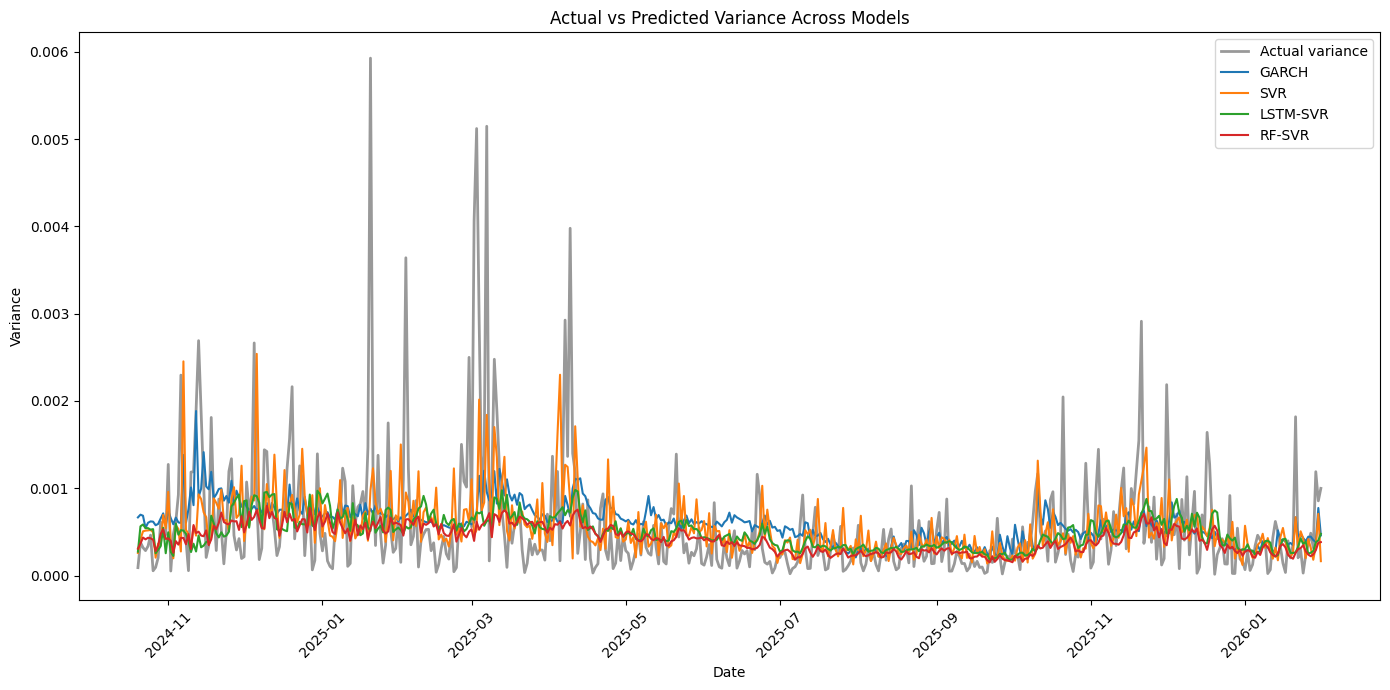

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read results
# -----------------------------
test_garch = pd.read_csv("benchmark garch/garch.csv")
test_svr = pd.read_csv("SVR/results/svr_test_results.csv")
test_lstmsvr = pd.read_csv("lstm-regimeaware/results/lstm-svr1.csv")
test_rfsvr = pd.read_csv("rf-regimeaware/results/test_rf_results.csv")

# -----------------------------
# 2. Convert to variance scale
# -----------------------------
test_garch["actual_var"] = np.exp(test_garch["actual_var"])
test_garch["pred_garch"] = np.exp(test_garch["var_garch_bench"])

test_svr["pred_svr"] = test_svr["pred_var"]

test_lstmsvr["actual_var"] = np.exp(test_lstmsvr["actual_log_var"])
test_lstmsvr["pred_lstmsvr"] = np.exp(test_lstmsvr["log_var_svr"])

test_rfsvr["actual_var"] = np.exp(test_rfsvr["actual_log_var"])
test_rfsvr["pred_rfsvr"] = np.exp(test_rfsvr["log_var_svr"])

# -----------------------------
# 3. Keep only needed columns
#    adjust "date" if your column name differs
# -----------------------------
garch_df = test_garch[["date", "actual_var", "pred_garch"]].copy()
svr_df = test_svr[["date", "actual_var", "pred_svr"]].copy()
lstm_df = test_lstmsvr[["date", "actual_var", "pred_lstmsvr"]].copy()
rf_df = test_rfsvr[["date", "actual_var", "pred_rfsvr"]].copy()

# -----------------------------
# 4. Convert dates
# -----------------------------
for df in [garch_df, svr_df, lstm_df, rf_df]:
    df["date"] = pd.to_datetime(df["date"])

# -----------------------------
# 5. Merge everything on date
#    Use one actual_var column from one file
# -----------------------------
plot_df = (
    garch_df[["date", "actual_var", "pred_garch"]]
    .merge(svr_df[["date", "pred_svr"]], on="date", how="inner")
    .merge(lstm_df[["date", "pred_lstmsvr"]], on="date", how="inner")
    .merge(rf_df[["date", "pred_rfsvr"]], on="date", how="inner")
    .sort_values("date")
)

# -----------------------------
# 6. Plot
# -----------------------------
plt.figure(figsize=(14, 7))
plt.plot(
    plot_df["date"],
    plot_df["actual_var"],
    label="Actual variance",
    color="black",
    linewidth=2,
    alpha=0.4
)

# models (clear colors)
plt.plot(plot_df["date"], plot_df["pred_garch"], label="GARCH")
plt.plot(plot_df["date"], plot_df["pred_svr"], label="SVR")
plt.plot(plot_df["date"], plot_df["pred_lstmsvr"], label="LSTM-SVR")
plt.plot(plot_df["date"], plot_df["pred_rfsvr"], label="RF-SVR")

plt.title("Actual vs Predicted Variance Across Models")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()